[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_01_ciclo_vida_ml.ipynb)

# Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Recorrer el ciclo de vida completo de un proyecto de Machine Learning — desde la recolección de datos hasta la evaluación y serialización del modelo — utilizando el dataset **Heart Disease** de UCI y las herramientas del ecosistema Scikit-learn.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Cargamos el **Heart Disease dataset** directamente desde el repositorio UCI Machine Learning a través de una URL pública.

| Variable | Descripción |
|---|---|
| `age` | Edad del paciente |
| `sex` | Sexo (1 = masculino, 0 = femenino) |
| `cp` | Tipo de dolor torácico (0-3) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol` | Colesterol sérico (mg/dl) |
| `fbs` | Glucosa en ayunas > 120 mg/dl (1 = sí) |
| `restecg` | Resultados electrocardiográficos en reposo |
| `thalach` | Frecuencia cardíaca máxima alcanzada |
| `exang` | Angina inducida por ejercicio (1 = sí) |
| `oldpeak` | Depresión del ST inducida por ejercicio |
| `slope` | Pendiente del segmento ST |
| `ca` | Número de vasos coloreados por fluoroscopía |
| `thal` | Thalassemia (0-3) |
| `target` | Diagnóstico de enfermedad cardíaca (1 = presente, 0 = ausente) |

In [2]:
DATA_PATH = 'education_career_success.csv'

try:
    df = pd.read_csv(DATA_PATH)
    print(
        f'Dataset cargado correctamente — '
        f'{df.shape[0]} registros, '
        f'{df.shape[1]} columnas'
    )
except Exception as e:
    print(f'Error al cargar el dataset: {e}')
    raise

df.head()


print('=' * 60)
print('COLUMNAS DEL DATASET')
print('=' * 60)

for i, column in enumerate(df.columns, start=1):
    print(f'{i:02d}. {column}')


descripcion = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': df.dtypes.astype(str),
    'Valores_unicos': [df[col].nunique() for col in df.columns],
    'Nulos': [df[col].isnull().sum() for col in df.columns]
})

descripcion

Dataset cargado correctamente — 400 registros, 19 columnas
COLUMNAS DEL DATASET
01. Student_ID
02. Age
03. Gender
04. High_School_GPA
05. SAT_Score
06. University_GPA
07. Field_of_Study
08. Internships_Completed
09. Projects_Completed
10. Certifications
11. Soft_Skills_Score
12. Networking_Score
13. Job_Offers
14. Starting_Salary
15. Career_Satisfaction
16. Years_to_Promotion
17. Current_Job_Level
18. Work_Life_Balance
19. Entrepreneurship


,Variable,Tipo,Valores_unicos,Nulos
Student_ID,Student_ID,str,400,0
Age,Age,int64,5,0
Gender,Gender,str,2,0
High_School_GPA,High_School_GPA,float64,8,0
SAT_Score,SAT_Score,int64,35,0
University_GPA,University_GPA,float64,13,0
Field_of_Study,Field_of_Study,str,11,0
Internships_Completed,Internships_Completed,int64,5,0
Projects_Completed,Projects_Completed,int64,8,0
Certifications,Certifications,int64,6,0


---
## 3. Etapa 2 — Exploración y preparación de datos

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             400 non-null    str    
 1   Age                    400 non-null    int64  
 2   Gender                 400 non-null    str    
 3   High_School_GPA        400 non-null    float64
 4   SAT_Score              400 non-null    int64  
 5   University_GPA         400 non-null    float64
 6   Field_of_Study         400 non-null    str    
 7   Internships_Completed  400 non-null    int64  
 8   Projects_Completed     400 non-null    int64  
 9   Certifications         400 non-null    int64  
 10  Soft_Skills_Score      400 non-null    int64  
 11  Networking_Score       400 non-null    int64  
 12  Job_Offers             400 non-null    int64  
 13  Starting_Salary        400 non-null    int64  
 14  Career_Satisfaction    400 non-null  

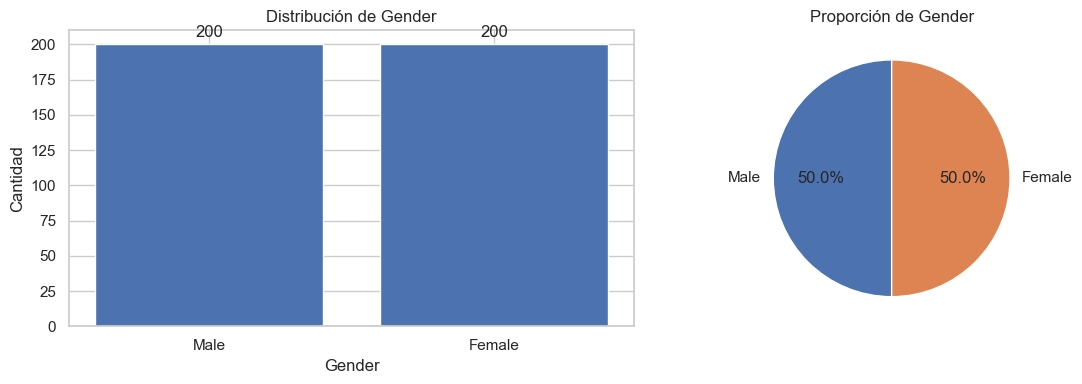

Variables numéricas seleccionadas:
- Age
- High_School_GPA
- SAT_Score
- University_GPA
- Internships_Completed
- Projects_Completed
- Certifications
- Soft_Skills_Score
- Networking_Score
- Job_Offers
- Starting_Salary
- Career_Satisfaction
- Years_to_Promotion
- Work_Life_Balance


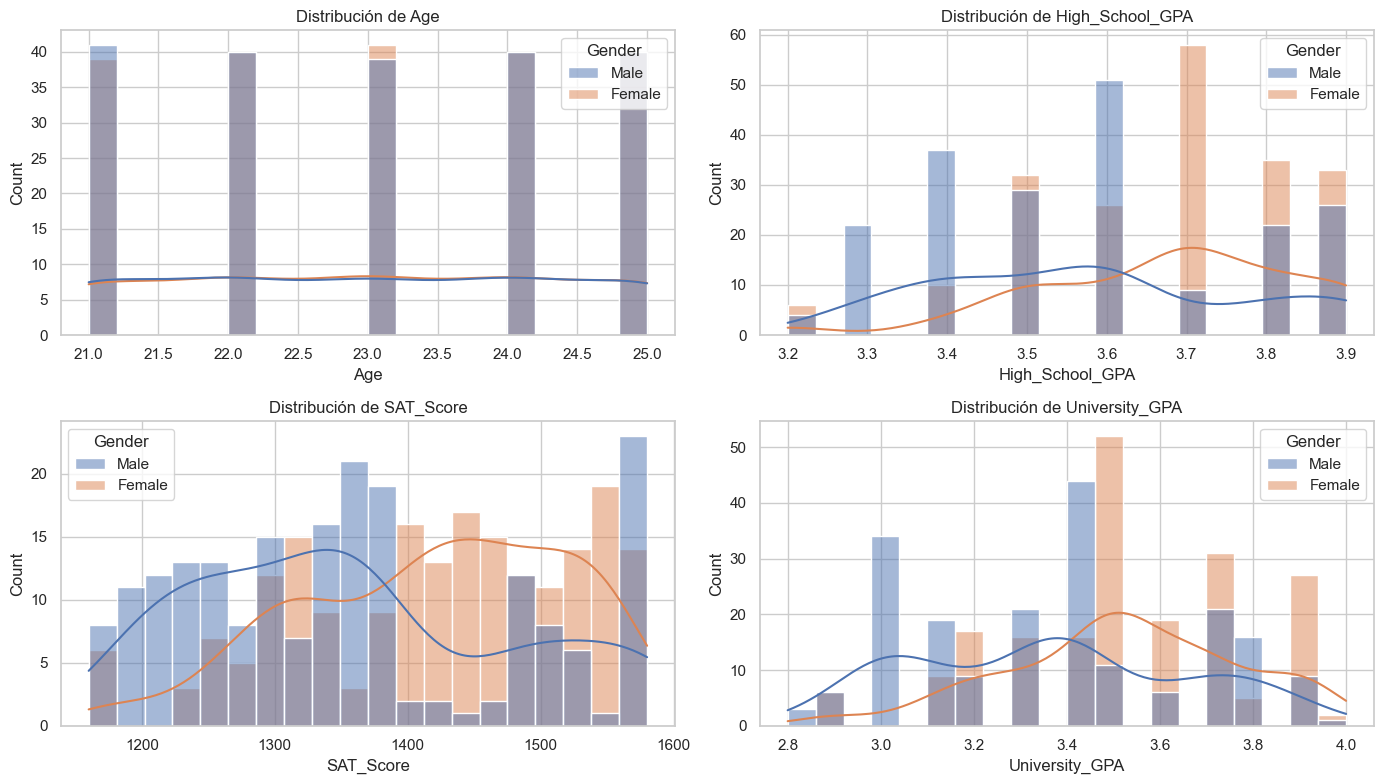


DISTRIBUCIÓN DE Field_of_Study
Field_of_Study
Business            72
Engineering         58
Psychology          55
Computer Science    49
Law                 44
Marketing           44
Medicine            35
Arts                32
Finance              5
Education            3
Nursing              3
Name: count, dtype: int64

DISTRIBUCIÓN DE Current_Job_Level
Current_Job_Level
Mid       261
Entry      80
Senior     59
Name: count, dtype: int64

DISTRIBUCIÓN DE Entrepreneurship
Entrepreneurship
No    400
Name: count, dtype: int64


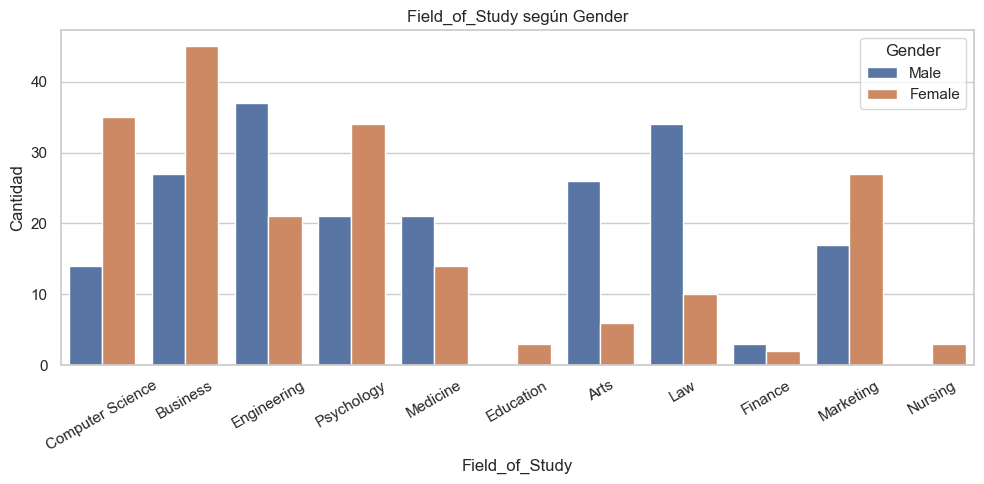

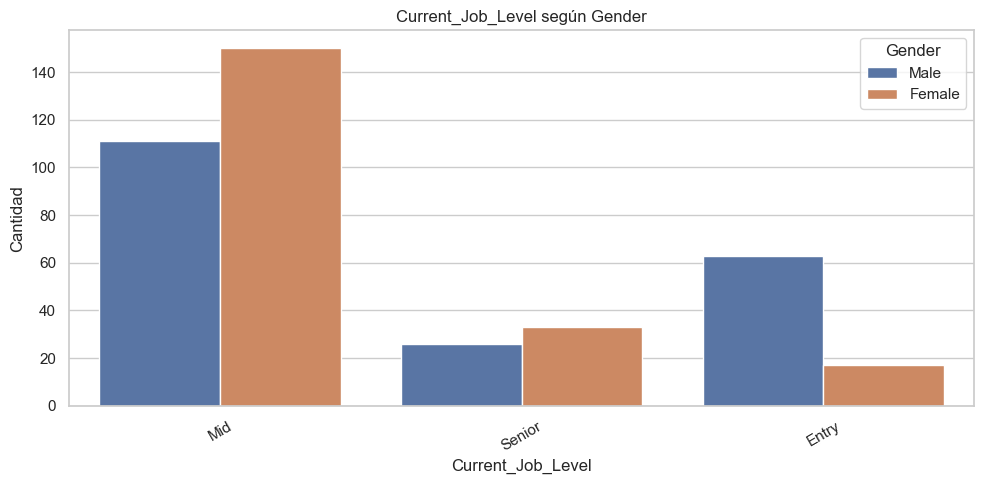

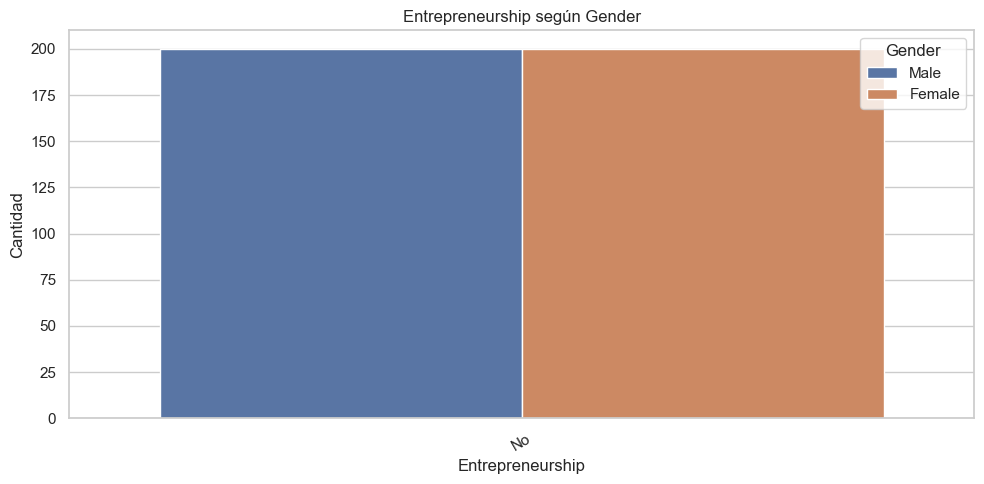

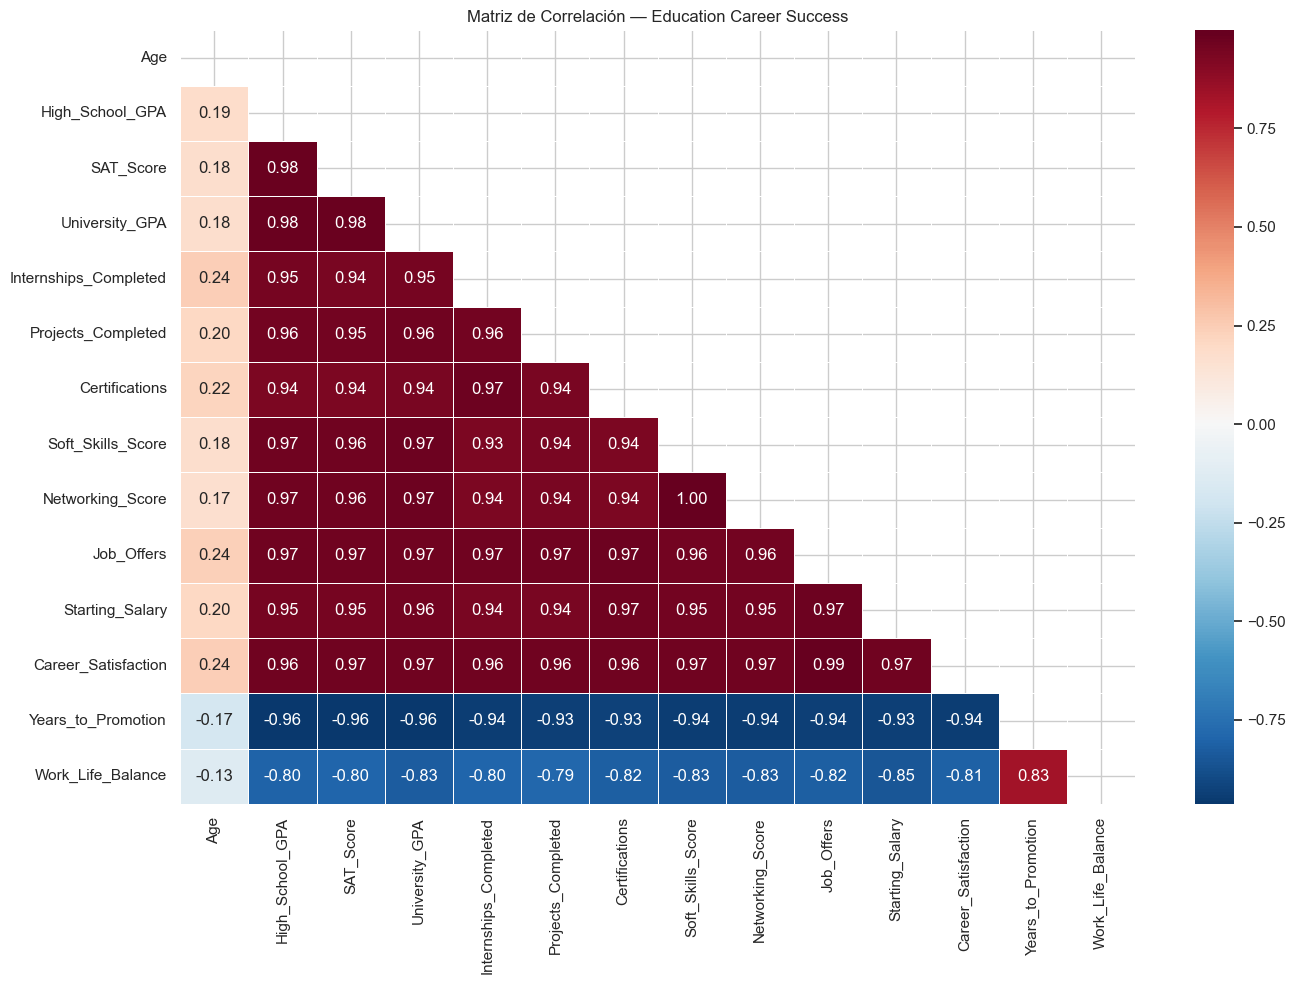

In [3]:
print('=' * 60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('=' * 60)

df.info()


print('=' * 60)
print('ESTADÍSTICAS DESCRIPTIVAS')
print('=' * 60)

df.describe(include='all').round(2)


print('=' * 60)
print('VALORES NULOS')
print('=' * 60)
print(df.isnull().sum())

print('\n' + '=' * 60)
print('REGISTROS DUPLICADOS')
print('=' * 60)
print(f'Duplicados encontrados: {df.duplicated().sum()}')


duplicados = df.duplicated().sum()

if duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Se eliminaron {duplicados} registros duplicados.')
else:
    print('No existen registros duplicados.')

print(f'Total de registros actuales: {len(df)}')


print('=' * 60)
print('DISTRIBUCIÓN DE GENDER')
print('=' * 60)

gender_counts = df['Gender'].value_counts()
print(gender_counts)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(gender_counts.index, gender_counts.values)
axes[0].set_title('Distribución de Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Cantidad')

for i, value in enumerate(gender_counts.values):
    axes[0].text(i, value + 5, str(value), ha='center')

axes[1].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporción de Gender')

plt.tight_layout()
plt.show()


# Variables numéricas del nuevo dataset
num_cols = [
    'Age',
    'High_School_GPA',
    'SAT_Score',
    'University_GPA',
    'Internships_Completed',
    'Projects_Completed',
    'Certifications',
    'Soft_Skills_Score',
    'Networking_Score',
    'Job_Offers',
    'Starting_Salary',
    'Career_Satisfaction',
    'Years_to_Promotion',
    'Work_Life_Balance'
]

print('Variables numéricas seleccionadas:')
for column in num_cols:
    print(f'- {column}')


fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, column in zip(axes.ravel(), num_cols[:4]):
    sns.histplot(
        data=df,
        x=column,
        hue='Gender',
        kde=True,
        bins=20,
        ax=ax
    )
    ax.set_title(f'Distribución de {column}')

plt.tight_layout()
plt.show()


# Variables categóricas del nuevo dataset
categorical_cols = [
    'Field_of_Study',
    'Current_Job_Level',
    'Entrepreneurship'
]

for column in categorical_cols:
    print('\n' + '=' * 60)
    print(f'DISTRIBUCIÓN DE {column}')
    print('=' * 60)
    print(df[column].value_counts())


for column in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=column, hue='Gender')
    plt.title(f'{column} según Gender')
    plt.xlabel(column)
    plt.ylabel('Cantidad')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)

plt.title('Matriz de Correlación — Education Career Success')
plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [4]:
X = df.drop(columns=['Gender', 'Student_ID'])
y = df['Gender']

print('=' * 60)
print('SEPARACIÓN DE FEATURES Y TARGET')
print('=' * 60)
print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')
print('\nClases del target:')
print(y.value_counts())


print('Variables utilizadas por el modelo:')
for column in X.columns:
    print(f'- {column}')


numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('=' * 60)
print('VARIABLES NUMÉRICAS')
print('=' * 60)
print(numeric_features)

print('\n' + '=' * 60)
print('VARIABLES CATEGÓRICAS')
print('=' * 60)
print(categorical_features)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print('Preprocesamiento configurado correctamente.')


# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('=' * 60)
print('DIVISIÓN TRAIN / TEST')
print('=' * 60)
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')

print('\nProporción Gender en train:')
print(y_train.value_counts(normalize=True).round(3))

print('\nProporción Gender en test:')
print(y_test.value_counts(normalize=True).round(3))

SEPARACIÓN DE FEATURES Y TARGET
Features: (400, 17)
Target:   (400,)

Clases del target:
Gender
Male      200
Female    200
Name: count, dtype: int64
Variables utilizadas por el modelo:
- Age
- High_School_GPA
- SAT_Score
- University_GPA
- Field_of_Study
- Internships_Completed
- Projects_Completed
- Certifications
- Soft_Skills_Score
- Networking_Score
- Job_Offers
- Starting_Salary
- Career_Satisfaction
- Years_to_Promotion
- Current_Job_Level
- Work_Life_Balance
- Entrepreneurship
VARIABLES NUMÉRICAS
['Age', 'High_School_GPA', 'SAT_Score', 'University_GPA', 'Internships_Completed', 'Projects_Completed', 'Certifications', 'Soft_Skills_Score', 'Networking_Score', 'Job_Offers', 'Starting_Salary', 'Career_Satisfaction', 'Years_to_Promotion', 'Work_Life_Balance']

VARIABLES CATEGÓRICAS
['Field_of_Study', 'Current_Job_Level', 'Entrepreneurship']
Preprocesamiento configurado correctamente.
DIVISIÓN TRAIN / TEST
X_train: (320, 17)  |  X_test: (80, 17)
y_train: (320,)  |  y_test: (80,)

Pro

C:\Users\ronyq\AppData\Local\Temp\ipykernel_18320\1052732968.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [5]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42)
}

resultados_cv = {}

print('=' * 60)
print('VALIDACIÓN CRUZADA (5-FOLD) — ACCURACY')
print('=' * 60)

for nombre, modelo in modelos.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', modelo)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    resultados_cv[nombre] = scores

    print(f'{nombre:22s} → '
          f'accuracy = {scores.mean():.4f} ± {scores.std():.4f}')

# Entrenar los tres modelos sobre todo el train
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', modelo)
    ])
    pipe.fit(X_train, y_train)
    modelos_entrenados[nombre] = pipe
    print(f'Modelo entrenado: {nombre}')

VALIDACIÓN CRUZADA (5-FOLD) — ACCURACY
Logistic Regression    → accuracy = 0.8219 ± 0.0290
Decision Tree          → accuracy = 0.9344 ± 0.0334
Random Forest          → accuracy = 0.9437 ± 0.0337
Modelo entrenado: Logistic Regression
Modelo entrenado: Decision Tree
Modelo entrenado: Random Forest


---
## 6. Etapa 5 — Evaluación del mejor modelo

MEJOR MODELO: Random Forest

Accuracy : 0.9375
Precision: 0.9268
Recall   : 0.95
F1-score : 0.9383

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

      Female       0.95      0.93      0.94        40
        Male       0.93      0.95      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80



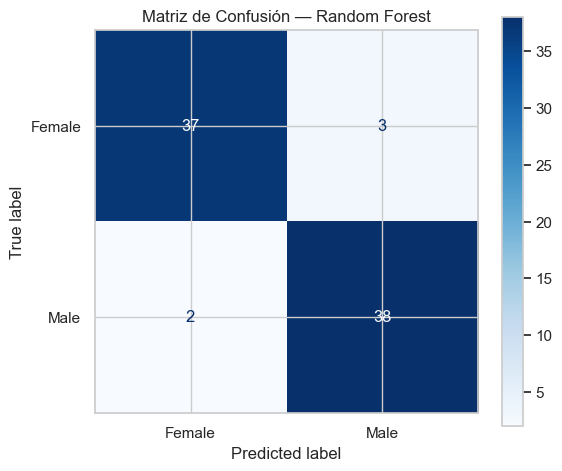

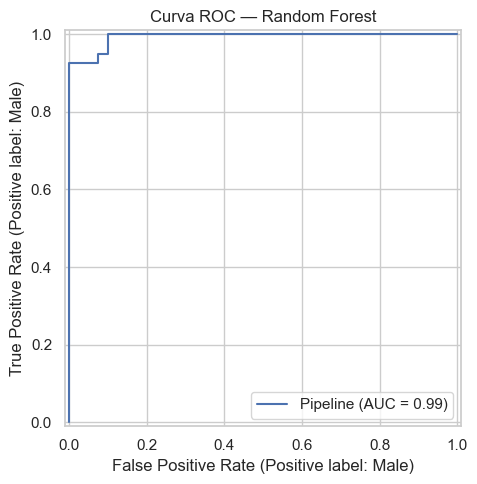

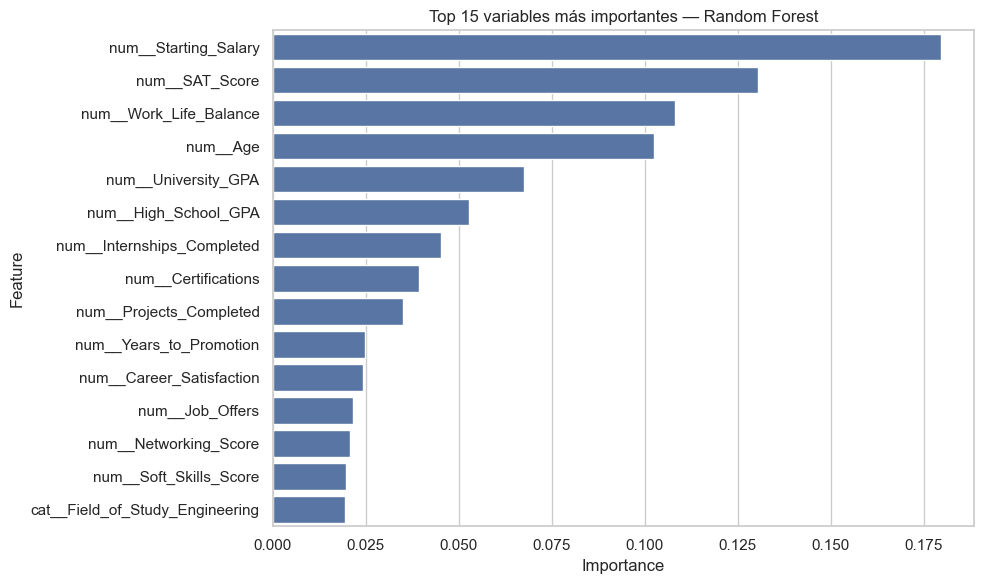

In [6]:
mejor_nombre = max(resultados_cv, key=lambda k: resultados_cv[k].mean())
mejor_modelo = modelos_entrenados[mejor_nombre]

print('=' * 60)
print(f'MEJOR MODELO: {mejor_nombre}')
print('=' * 60)

y_pred = mejor_modelo.predict(X_test)

print('\nAccuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred, pos_label='Male'), 4))
print('Recall   :', round(recall_score(y_test, y_pred, pos_label='Male'), 4))
print('F1-score :', round(f1_score(y_test, y_pred, pos_label='Male'), 4))

print('\n' + '=' * 60)
print('REPORTE DE CLASIFICACIÓN')
print('=' * 60)
print(classification_report(y_test, y_pred))


# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    mejor_modelo,
    X_test,
    y_test,
    ax=ax,
    cmap='Blues'
)
plt.title(f'Matriz de Confusión — {mejor_nombre}')
plt.tight_layout()
plt.show()


# Curva ROC (One-vs-Rest para clasificación binaria)
try:
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(mejor_modelo, X_test, y_test, ax=ax)
    plt.title(f'Curva ROC — {mejor_nombre}')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'No se pudo generar la curva ROC: {e}')


# Importancia de variables (si el modelo lo permite)
clf = mejor_modelo.named_steps['classifier']
if hasattr(clf, 'feature_importances_') or hasattr(clf, 'coef_'):
    feature_names = mejor_modelo.named_steps['preprocessor'].get_feature_names_out()

    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
    else:
        importances = np.abs(clf.coef_[0])

    importancia = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importancia, x='Importance', y='Feature')
    plt.title(f'Top 15 variables más importantes — {mejor_nombre}')
    plt.tight_layout()
    plt.show()

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [7]:
MODEL_PATH = 'modelo_gender_pipeline.joblib'
joblib.dump(mejor_modelo, MODEL_PATH)
print(f'Modelo serializado en: {MODEL_PATH}')


# Cargar y usar el modelo para inferencia
modelo_cargado = joblib.load(MODEL_PATH)

nuevo_registro = X_test.iloc[[0]]
prediccion = modelo_cargado.predict(nuevo_registro)
probabilidad = modelo_cargado.predict_proba(nuevo_registro)

print('=' * 60)
print('INFERENCIA SOBRE UN NUEVO REGISTRO')
print('=' * 60)
print(f'Predicción: {prediccion[0]}')
print(f'Probabilidades: {dict(zip(modelo_cargado.classes_, probabilidad[0].round(4)))}')
print(f'Valor real: {y_test.iloc[0]}')


Modelo serializado en: modelo_gender_pipeline.joblib
INFERENCIA SOBRE UN NUEVO REGISTRO
Predicción: Female
Probabilidades: {'Female': np.float64(0.94), 'Male': np.float64(0.06)}
Valor real: Female


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Descarga del dataset Heart Disease (UCI/OpenML) | `pandas`, URL pública |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |

In [8]:
print('RESUMEN DEL CICLO DE VIDA')
print("""
| Etapa          | Qué hicimos                                              | Herramientas                       |
|----------------|----------------------------------------------------------|------------------------------------|
| Recolección    | Carga del dataset Education Career Success               | pandas                             |
| Exploración    | Distribuciones, correlaciones, nulos, duplicados         | seaborn, matplotlib                |
| Preparación    | Limpieza, split estratificado 80/20                      | train_test_split                   |
| Entrenamiento  | 3 modelos con pipelines + validación cruzada 5-fold      | Pipeline, cross_val_score          |
| Evaluación     | Accuracy, precision, recall, F1, ROC, matriz confusión   | classification_report, RocCurve    |
| Despliegue     | Serialización con joblib + función de inferencia         | joblib                             |
""")

RESUMEN DEL CICLO DE VIDA

| Etapa          | Qué hicimos                                              | Herramientas                       |
|----------------|----------------------------------------------------------|------------------------------------|
| Recolección    | Carga del dataset Education Career Success               | pandas                             |
| Exploración    | Distribuciones, correlaciones, nulos, duplicados         | seaborn, matplotlib                |
| Preparación    | Limpieza, split estratificado 80/20                      | train_test_split                   |
| Entrenamiento  | 3 modelos con pipelines + validación cruzada 5-fold      | Pipeline, cross_val_score          |
| Evaluación     | Accuracy, precision, recall, F1, ROC, matriz confusión   | classification_report, RocCurve    |
| Despliegue     | Serialización con joblib + función de inferencia         | joblib                             |



---
## 9. Ejercicios propuestos

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del `RandomForestClassifier`. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset **Diabetes** de Scikit-learn (`sklearn.datasets.load_diabetes`) o el **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) y replique el ciclo de vida completo aplicado en esta sesión.

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*